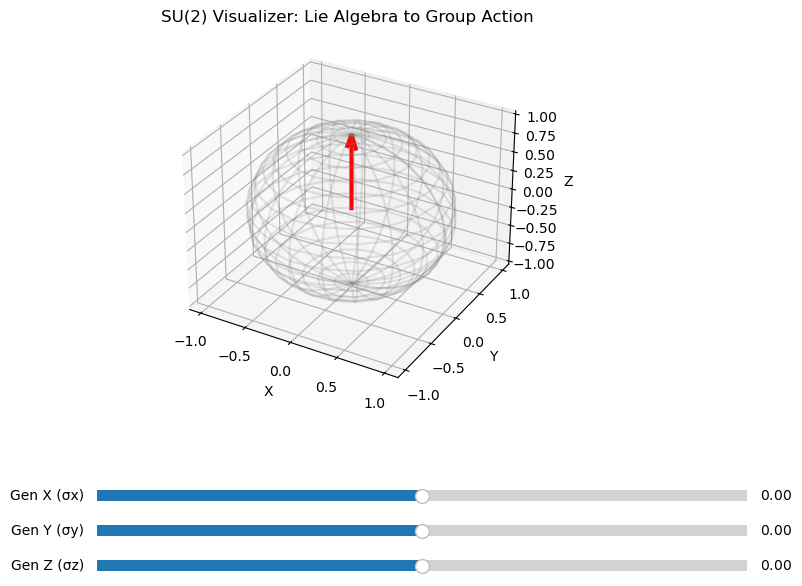

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from mpl_toolkits.mplot3d import Axes3D
from scipy.linalg import expm

# --- 初期設定 ---
# パウリ行列の定義
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)

# 初期状態: 上向きスピン |0> = (1, 0)
initial_state = np.array([1, 0], dtype=complex)

def get_bloch_vector(state):
    """
    複素2次元ベクトル(スピノル)を、3次元実ベクトル(ブロッホベクトル)に変換する
    x = <ψ|σx|ψ>, y = <ψ|σy|ψ>, z = <ψ|σz|ψ>
    """
    # 密度行列 rho = |ψ><ψ|
    rho = np.outer(state, np.conj(state))
    
    x = np.trace(np.dot(rho, sigma_x)).real
    y = np.trace(np.dot(rho, sigma_y)).real
    z = np.trace(np.dot(rho, sigma_z)).real
    return np.array([x, y, z])

# --- プロットの準備 ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
plt.subplots_adjust(left=0.1, bottom=0.35) # スライダー用のスペースを確保

# タイトル
ax.set_title("SU(2) Visualizer: Lie Algebra to Group Action")
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# ブロッホ球（ワイヤーフレーム）の描画
u = np.linspace(0, 2 * np.pi, 20)
v = np.linspace(0, np.pi, 20)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_wireframe(xs, ys, zs, color='gray', alpha=0.2)

# ベクトルの初期描画（矢印）
# 注意: quiverは始点(x,y,z)と成分(u,v,w)を取る
quiver = ax.quiver(0, 0, 0, 0, 0, 1, color='r', linewidth=3, arrow_length_ratio=0.2)

# 状態表示用のテキスト
text_display = fig.text(0.05, 0.8, "", fontsize=12, family='monospace')

# --- スライダーの設定 ---
# 軸の位置 [left, bottom, width, height]
ax_sx = plt.axes([0.25, 0.20, 0.65, 0.03])
ax_sy = plt.axes([0.25, 0.15, 0.65, 0.03])
ax_sz = plt.axes([0.25, 0.10, 0.65, 0.03])

# スライダーの作成（範囲は -2π 〜 2π とします）
slider_x = Slider(ax_sx, 'Gen X (σx)', -2*np.pi, 2*np.pi, valinit=0.0)
slider_y = Slider(ax_sy, 'Gen Y (σy)', -2*np.pi, 2*np.pi, valinit=0.0)
slider_z = Slider(ax_sz, 'Gen Z (σz)', -2*np.pi, 2*np.pi, valinit=0.0)

def update(val):
    """スライダーの値が変わったときに呼ばれる関数"""
    global quiver # 矢印を更新するためにglobal参照
    
    # 1. スライダーの値を取得（これがリー代数の係数）
    ax_val = slider_x.val
    ay_val = slider_y.val
    az_val = slider_z.val
    
    # 2. SU(2)行列の生成: U = exp(-i * (ax*σx + ay*σy + az*σz) / 2)
    # ハミルトニアン的な生成子 H = ax*σx + ay*σy + az*σz
    generator = ax_val * sigma_x + ay_val * sigma_y + az_val * sigma_z
    
    # 行列指数関数でLie群の元へ
    # 物理では回転角θに対して exp(-i σ θ / 2) なので、係数を角度とみなす
    U = expm(-1j * generator / 2)
    
    # 3. 状態の更新: |ψ'> = U |ψ>
    new_state = np.dot(U, initial_state)
    
    # 4. ブロッホベクトルの計算
    bx, by, bz = get_bloch_vector(new_state)
    
    # 5. 描画の更新
    # 古い矢印を消して新しい矢印を描く（matplotlibの3D quiverはupdateが難しいため再描画）
    quiver.remove()
    quiver = ax.quiver(0, 0, 0, bx, by, bz, color='r', linewidth=3, arrow_length_ratio=0.2)
    
    # テキスト情報の更新
    state_str = f"Complex State (C^2):\n a={new_state[0]:.2f}\n b={new_state[1]:.2f}\n\nBloch Vector (R^3):\n x={bx:.2f}\n y={by:.2f}\n z={bz:.2f}"
    text_display.set_text(state_str)
    
    fig.canvas.draw_idle()

# スライダーにイベントリスナーを登録
slider_x.on_changed(update)
slider_y.on_changed(update)
slider_z.on_changed(update)

plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from mpl_toolkits.mplot3d import Axes3D

# Jupyter用のインタラクティブウィジェット
import ipywidgets as widgets
from ipywidgets import interact

# --- 1. 計算ロジック（さきほどと同じ） ---
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
initial_state = np.array([1, 0], dtype=complex)

def get_bloch_vector(state):
    rho = np.outer(state, np.conj(state))
    x = np.trace(np.dot(rho, sigma_x)).real
    y = np.trace(np.dot(rho, sigma_y)).real
    z = np.trace(np.dot(rho, sigma_z)).real
    return x, y, z

# --- 2. 描画関数 ---
def plot_su2_rotation(ax_val, ay_val, az_val):
    # 行列の生成と回転計算
    generator = ax_val * sigma_x + ay_val * sigma_y + az_val * sigma_z
    U = expm(-1j * generator / 2)
    new_state = np.dot(U, initial_state)
    bx, by, bz = get_bloch_vector(new_state)
    
    # --- 描画処理 ---
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    
    # 視点の固定（これがないと動かしたときにガタつく）
    ax.view_init(elev=20, azim=45)
    ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1]); ax.set_zlim([-1, 1])
    ax.set_title(f"SU(2) Rotation\nBloch Vector: ({bx:.2f}, {by:.2f}, {bz:.2f})")
    
    # ワイヤーフレーム（球）
    u = np.linspace(0, 2 * np.pi, 20)
    v = np.linspace(0, np.pi, 20)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_wireframe(xs, ys, zs, color='gray', alpha=0.1)
    
    # ベクトル
    ax.quiver(0, 0, 0, bx, by, bz, color='red', linewidth=3, arrow_length_ratio=0.1)
    
    plt.show()

# --- 3. インタラクティブ実行 ---
print("スライダーを動かして SU(2) 回転を操作してください:")
interact(plot_su2_rotation, 
         ax_val=widgets.FloatSlider(min=-6.28, max=6.28, step=0.1, value=0, description='Gen X'),
         ay_val=widgets.FloatSlider(min=-6.28, max=6.28, step=0.1, value=0, description='Gen Y'),
         az_val=widgets.FloatSlider(min=-6.28, max=6.28, step=0.1, value=0, description='Gen Z'));

スライダーを動かして SU(2) 回転を操作してください:


interactive(children=(FloatSlider(value=0.0, description='Gen X', max=6.28, min=-6.28), FloatSlider(value=0.0,…